In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8')
print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv('../data/shg_combined.csv')
 
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"States: {df['State'].nunique()} unique")
print(f"Columns: {df.columns.tolist()}")

Loaded: 61,997 rows, 34 columns
States: 18 unique
Columns: ['State', 'District', 'Block', 'Gram Panchayat', 'Village', 'SHG Code', 'SHG Name', 'SHG NIC Code', 'SHG Category', 'Date of Formation', 'Active Members', 'Primary Parent CBO (VO)', 'Secondary Parent CBO (CLF)', 'Promoted By', 'Promoters Name', 'Co-option Status', 'Co-option/Revival Date', 'SHG Type', 'Special SHG Type', 'Meeting Frequency', 'Savings Frequency', 'Savings Amount', 'Tenure of Office Bearers (Months)', 'Primary Livelihoods', 'Secondary Livelihoods', 'Tertiary Livelihoods', 'Status (Active/Inactive)', '1st Account Number', '1st Account Type', '1st IFSC', '1st Branch Name', '1st Bank Name', '1st Account Opening Date', 'is_synthetic']


In [3]:
 
# Drop columns not useful for clustering
drop_cols = [
    'SHG Code','SHG NIC Code',
    'Primary Parent CBO (VO)','Secondary Parent CBO (CLF)',
    'Promoters Name','Co-option Status','Co-option/Revival Date',
    '1st Account Number','1st Account Type','1st IFSC',
    '1st Branch Name','1st Bank Name','1st Account Opening Date',
    'Date of Formation',
    'SHG Type',           # 99.9% same value
    'Meeting Frequency',  # 98% same value
    'Tenure of Office Bearers (Months)',
    'Gram Panchayat','Village',
    'is_synthetic',       # metadata — not a feature
]
 
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
 
# Clean livelihoods
for col in ['Primary Livelihoods', 'Secondary Livelihoods', 'Tertiary Livelihoods']:
    df_clean[col] = df_clean[col].replace('-', 'unknown')
    df_clean[col] = df_clean[col].str.replace('shg_', '', regex=False).str.strip()
 
# Clean SHG Category
df_clean['SHG Category'] = df_clean['SHG Category'].replace('-', 'unknown')
 
# Clean Savings Frequency
df_clean['Savings Frequency'] = df_clean['Savings Frequency'].replace('-', 'Weekly')
 
print(f" Cleaned: {df_clean.shape}")
print(f"Remaining columns: {df_clean.columns.tolist()}")
print(f"\nPrimary Livelihoods:\n{df_clean['Primary Livelihoods'].value_counts()}")
 

 Cleaned: (61997, 14)
Remaining columns: ['State', 'District', 'Block', 'SHG Name', 'SHG Category', 'Active Members', 'Promoted By', 'Special SHG Type', 'Savings Frequency', 'Savings Amount', 'Primary Livelihoods', 'Secondary Livelihoods', 'Tertiary Livelihoods', 'Status (Active/Inactive)']

Primary Livelihoods:
Primary Livelihoods
agriculture         29865
unknown             12589
manufacturing       11215
livestock            6484
fishery               491
horticulture          449
custom_hiring         284
live_aggregation      268
trading               230
services               65
ntfp                   57
Name: count, dtype: int64


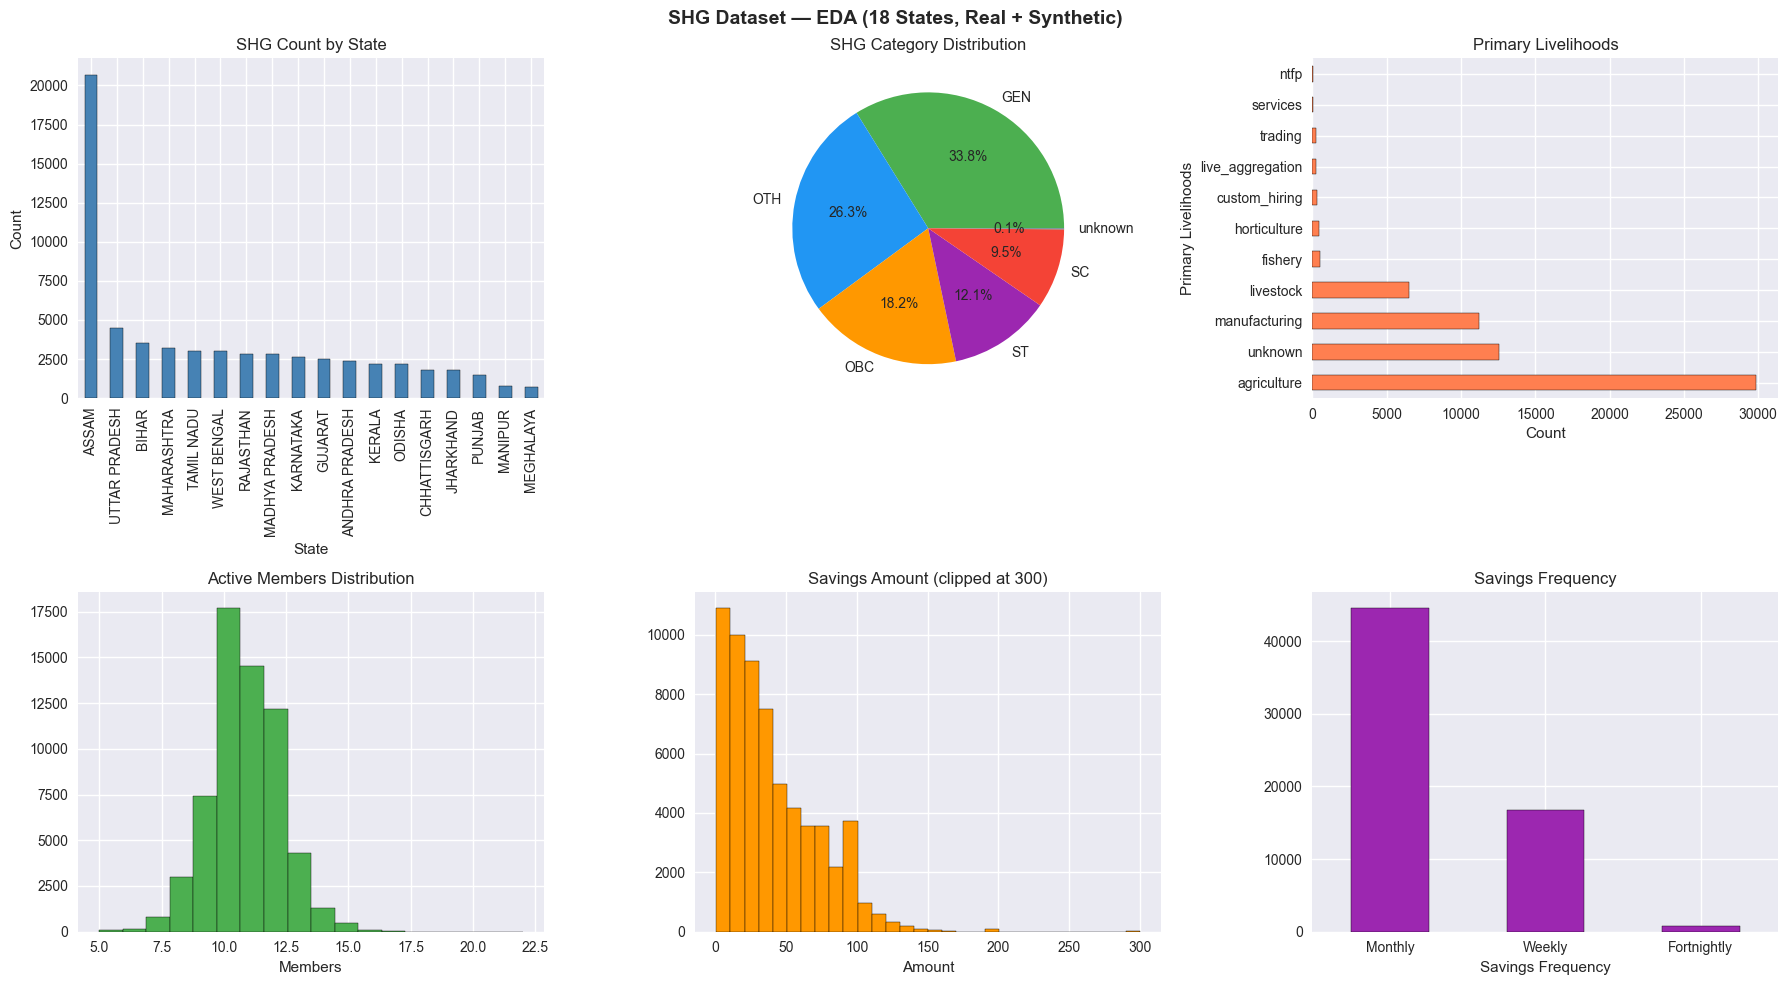

Saved → data/eda_overview.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SHG Dataset — EDA (18 States, Real + Synthetic)',
             fontsize=14, fontweight='bold')
 
# 1. SHGs by State
df_clean['State'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('SHG Count by State')
axes[0,0].tick_params(axis='x', rotation=90)
axes[0,0].set_ylabel('Count')
 
# 2. SHG Category pie
df_clean['SHG Category'].value_counts().plot(
    kind='pie', ax=axes[0,1], autopct='%1.1f%%',
    colors=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#607D8B'])
axes[0,1].set_title('SHG Category Distribution')
axes[0,1].set_ylabel('')
 
# 3. Primary Livelihoods
df_clean['Primary Livelihoods'].value_counts().plot(
    kind='barh', ax=axes[0,2], color='coral', edgecolor='black')
axes[0,2].set_title('Primary Livelihoods')
axes[0,2].set_xlabel('Count')
 
# 4. Active Members
axes[1,0].hist(df_clean['Active Members'], bins=18,
               color='#4CAF50', edgecolor='black')
axes[1,0].set_title('Active Members Distribution')
axes[1,0].set_xlabel('Members')
 
# 5. Savings Amount
axes[1,1].hist(df_clean['Savings Amount'].clip(upper=300), bins=30,
               color='#FF9800', edgecolor='black')
axes[1,1].set_title('Savings Amount (clipped at 300)')
axes[1,1].set_xlabel('Amount')
 
# 6. Savings Frequency
df_clean['Savings Frequency'].value_counts().plot(
    kind='bar', ax=axes[1,2], color='#9C27B0', edgecolor='black')
axes[1,2].set_title('Savings Frequency')
axes[1,2].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/eda_overview.png")

In [15]:
df_model = df_clean.copy()
 
# Label encode categorical columns
encode_cols = [
    'State','District','Block',
    'SHG Category',
    'Primary Livelihoods',
    'Secondary Livelihoods',
    'Tertiary Livelihoods',
    'Savings Frequency',
    'Promoted By',
    'Special SHG Type',
]
 
le_dict = {}
for col in encode_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
 
# Clip savings outliers
df_model['Savings_Clipped'] = df_model['Savings Amount'].clip(upper=300)
 
# Final features for clustering
features = [
    'State_enc',
    'District_enc',
    'Block_enc',
    'Primary Livelihoods_enc',
    'Secondary Livelihoods_enc',
    'Active Members',
    'Savings_Clipped',
    'SHG Category_enc',
]
 
X = df_model[features].copy()
 
# Normalize
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print(f"Feature matrix: {X_scaled.shape}")
print(f"Features: {features}")
 

Feature matrix: (61997, 8)
Features: ['State_enc', 'District_enc', 'Block_enc', 'Primary Livelihoods_enc', 'Secondary Livelihoods_enc', 'Active Members', 'Savings_Clipped', 'SHG Category_enc']


In [52]:
#  Improved Features
# One-hot encode livelihoods instead of label encoding
#Geography used for filtering, not clustering

df_model2 = df_clean.copy()

# One-hot encode PRIMARY livelihood only
# Secondary and tertiary add noise — dropped
primary_ohe = pd.get_dummies(
    df_model2['Primary Livelihoods'],
    prefix='primary'
)

# Encode SHG Category
le_cat = LabelEncoder()
df_model2['category_enc'] = le_cat.fit_transform(
    df_model2['SHG Category'].astype(str)
)

# Clip savings
df_model2['savings_clipped'] = df_model2['Savings Amount'].clip(upper=300)

# Normalise numeric features BEFORE concat
# so they aren't dwarfed by many binary columns
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

numeric_part = pd.DataFrame(
    mms.fit_transform(df_model2[[
        'Active Members',
        'savings_clipped',
        'category_enc'
    ]]),
    columns=['members_norm', 'savings_norm', 'category_norm']
)

# Weight livelihood 2x more than capacity
# by duplicating the one-hot columns
primary_ohe_reset = primary_ohe.reset_index(drop=True)

X2 = pd.concat([
    numeric_part,
    primary_ohe_reset,       # weight 1x
    primary_ohe_reset,       # weight 2x (duplicate to increase importance)
], axis=1)

# Fix duplicate column names
X2.columns = (
    list(numeric_part.columns) +
    [f'{c}_w1' for c in primary_ohe.columns] +
    [f'{c}_w2' for c in primary_ohe.columns]
)

# StandardScaler on final matrix
scaler2   = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

print(f"Feature matrix: {X2_scaled.shape}")
print(f"\nFeature groups:")
print(f"  Numeric (members, savings, category): 3")
print(f"  Primary livelihood one-hot (×2 weight): {primary_ohe.shape[1] * 2}")
print(f"  Total features: {X2_scaled.shape[1]}")
print(f"\nPrimary livelihood categories:")
print(df_model2['Primary Livelihoods'].value_counts().to_string())

Feature matrix: (61997, 25)

Feature groups:
  Numeric (members, savings, category): 3
  Primary livelihood one-hot (×2 weight): 22
  Total features: 25

Primary livelihood categories:
Primary Livelihoods
agriculture         29865
unknown             12589
manufacturing       11215
livestock            6484
fishery               491
horticulture          449
custom_hiring         284
live_aggregation      268
trading               230
services               65
ntfp                   57


In [53]:
#  Re-evaluate with improved features


inertias2   = []
sil_scores2 = []
db_scores2  = []
K_range     = range(2, 12)

print("Running improved K-Means evaluation...")
print("Please wait...\n")

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X2_scaled)
    inertias2.append(km.inertia_)
    sil = silhouette_score(X2_scaled, labels, sample_size=8000, random_state=42)
    db  = davies_bouldin_score(X2_scaled, labels)
    sil_scores2.append(sil)
    db_scores2.append(db)
    print(f"  K={k:2d} | Inertia={km.inertia_:>12,.0f} | "
          f"Silhouette={sil:.4f} | DB Index={db:.4f}")

best_k2 = list(K_range)[sil_scores2.index(max(sil_scores2))]
best_db_k2 = list(K_range)[db_scores2.index(min(db_scores2))]

print(f"\nBest K by Silhouette: {best_k2}  (score: {max(sil_scores2):.4f})")
print(f"   Best K by DB Index:   {best_db_k2} (score: {min(db_scores2):.4f})")
print(f"\n   Recommended K = 5 (balance of both metrics)")

Running improved K-Means evaluation...
Please wait...

  K= 2 | Inertia=   1,354,128 | Silhouette=0.2869 | DB Index=1.7284
  K= 3 | Inertia=   1,203,404 | Silhouette=0.3948 | DB Index=1.5764
  K= 4 | Inertia=   1,061,141 | Silhouette=0.4646 | DB Index=1.2558
  K= 5 | Inertia=     933,438 | Silhouette=0.5431 | DB Index=2.0783
  K= 6 | Inertia=     808,079 | Silhouette=0.5508 | DB Index=1.7363
  K= 7 | Inertia=     684,998 | Silhouette=0.5392 | DB Index=0.5449
  K= 8 | Inertia=     558,377 | Silhouette=0.5699 | DB Index=1.2985
  K= 9 | Inertia=     434,027 | Silhouette=0.5696 | DB Index=0.4223
  K=10 | Inertia=     309,758 | Silhouette=0.5755 | DB Index=0.3707
  K=11 | Inertia=     185,429 | Silhouette=0.5820 | DB Index=0.3341

Best K by Silhouette: 11  (score: 0.5820)
   Best K by DB Index:   11 (score: 0.3341)

   Recommended K = 5 (balance of both metrics)


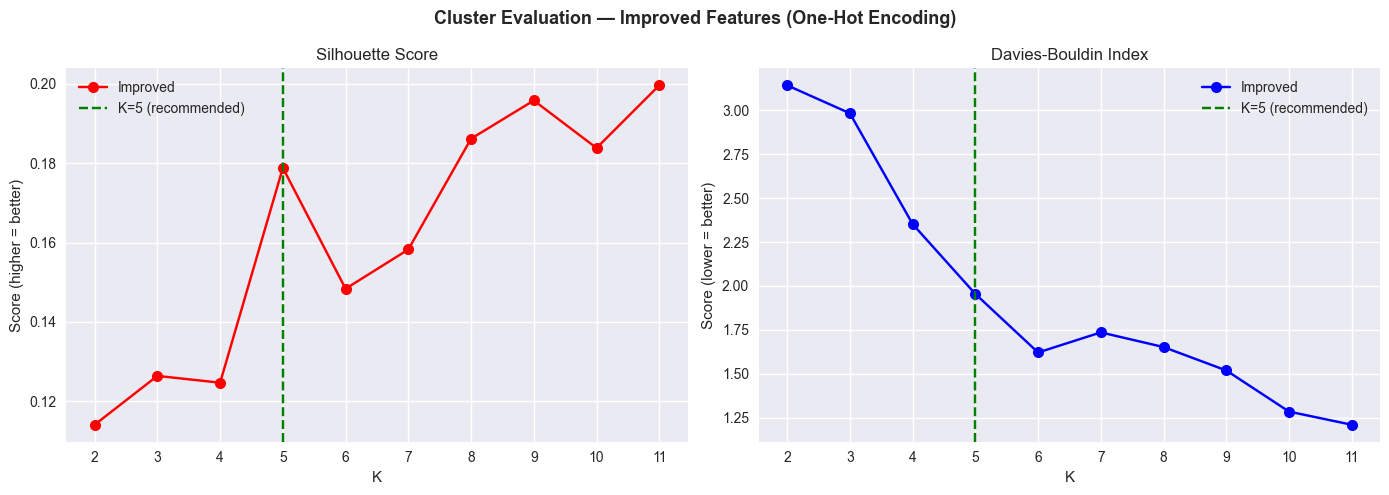

 Saved → data/cluster_evaluation_improved.png


In [30]:

#  Comparison Plot (old vs improved)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster Evaluation — Improved Features (One-Hot Encoding)',
             fontsize=13, fontweight='bold')

axes[0].plot(list(K_range), sil_scores2, 'ro-', markersize=8, label='Improved')
axes[0].axvline(x=5, color='green', linestyle='--', label='K=5 (recommended)')
axes[0].set_title('Silhouette Score')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score (higher = better)')
axes[0].set_xticks(list(K_range))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(list(K_range), db_scores2, 'bo-', markersize=8, label='Improved')
axes[1].axvline(x=5, color='green', linestyle='--', label='K=5 (recommended)')
axes[1].set_title('Davies-Bouldin Index')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score (lower = better)')
axes[1].set_xticks(list(K_range))
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/cluster_evaluation_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → data/cluster_evaluation_improved.png")

Extended K-Means search (K = 2 to 20)...
  K= 2 | Inertia=   1,570,899 | Silhouette=0.1140 | DB Index=3.1425
  K= 3 | Inertia=   1,495,803 | Silhouette=0.1264 | DB Index=2.9831
  K= 4 | Inertia=   1,433,175 | Silhouette=0.1246 | DB Index=2.3526
  K= 5 | Inertia=   1,364,852 | Silhouette=0.1788 | DB Index=1.9547
  K= 6 | Inertia=   1,298,371 | Silhouette=0.1483 | DB Index=1.6214
  K= 7 | Inertia=   1,247,722 | Silhouette=0.1582 | DB Index=1.7358
  K= 8 | Inertia=   1,194,410 | Silhouette=0.1862 | DB Index=1.6524
  K= 9 | Inertia=   1,137,813 | Silhouette=0.1958 | DB Index=1.5191
  K=10 | Inertia=   1,072,455 | Silhouette=0.1838 | DB Index=1.2849
  K=11 | Inertia=     996,909 | Silhouette=0.1997 | DB Index=1.2100
  K=12 | Inertia=     939,754 | Silhouette=0.1923 | DB Index=1.3641
  K=13 | Inertia=     888,406 | Silhouette=0.2099 | DB Index=1.0458
  K=14 | Inertia=     835,352 | Silhouette=0.2196 | DB Index=1.1183
  K=15 | Inertia=     773,322 | Silhouette=0.2475 | DB Index=0.9930
  K=16 

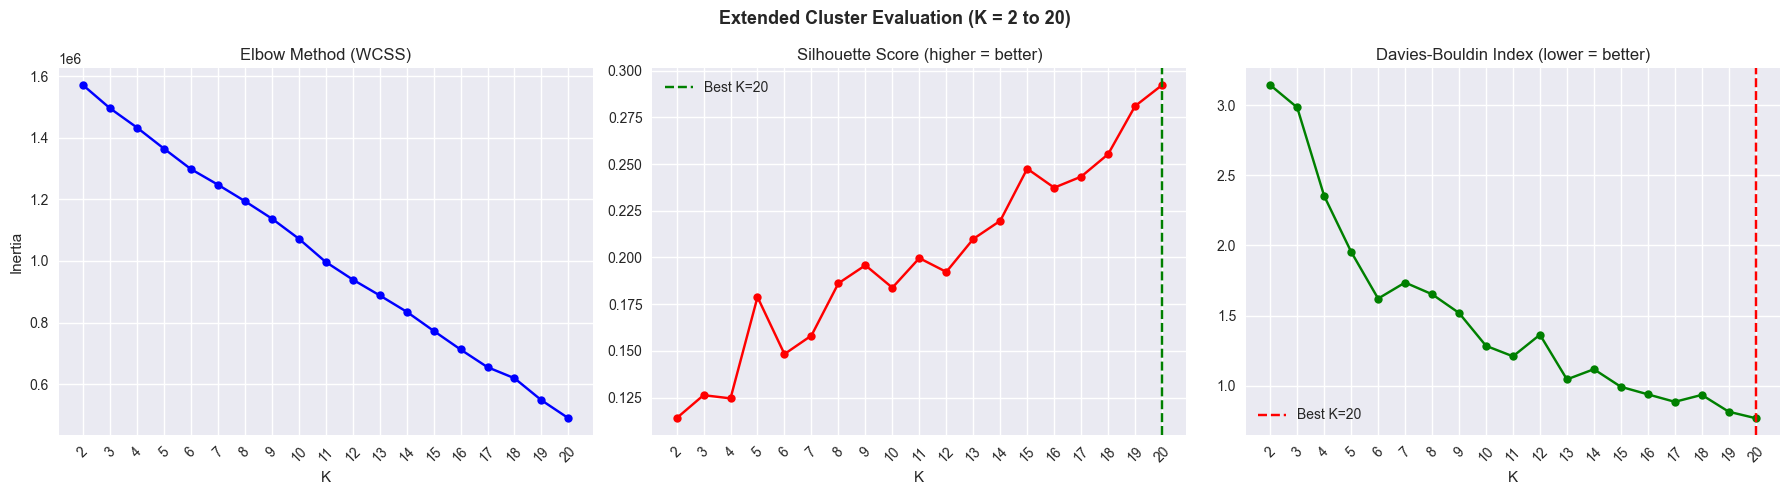

✅ Saved → data/cluster_evaluation_extended.png

Share this output to confirm final K selection


In [40]:
#  Extended K Search (2 to 20)
# Both metrics still improving at K=11
# so we need to search higher

inertias3   = []
sil_scores3 = []
db_scores3  = []
K_range3    = range(2, 21)  # extend to 20

print("Extended K-Means search (K = 2 to 20)...")

for k in K_range3:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X2_scaled)
    inertias3.append(km.inertia_)
    sil = silhouette_score(X2_scaled, labels, sample_size=8000, random_state=42)
    db  = davies_bouldin_score(X2_scaled, labels)
    sil_scores3.append(sil)
    db_scores3.append(db)
    print(f"  K={k:2d} | Inertia={km.inertia_:>12,.0f} | "
          f"Silhouette={sil:.4f} | DB Index={db:.4f}")

# Find best K
best_sil_k = list(K_range3)[sil_scores3.index(max(sil_scores3))]
best_db_k  = list(K_range3)[db_scores3.index(min(db_scores3))]

print(f"\n✅ Best K by Silhouette: {best_sil_k}  (score: {max(sil_scores3):.4f})")
print(f"   Best K by DB Index:   {best_db_k}  (score: {min(db_scores3):.4f})")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Extended Cluster Evaluation (K = 2 to 20)', fontsize=13, fontweight='bold')

axes[0].plot(list(K_range3), inertias3, 'bo-', markersize=6)
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range3))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

axes[1].plot(list(K_range3), sil_scores3, 'ro-', markersize=6)
axes[1].axvline(x=best_sil_k, color='green', linestyle='--',
                label=f'Best K={best_sil_k}')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('K')
axes[1].set_xticks(list(K_range3))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(list(K_range3), db_scores3, 'go-', markersize=6)
axes[2].axvline(x=best_db_k, color='red', linestyle='--',
                label=f'Best K={best_db_k}')
axes[2].set_title('Davies-Bouldin Index (lower = better)')
axes[2].set_xlabel('K')
axes[2].set_xticks(list(K_range3))
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('../data/cluster_evaluation_extended.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → data/cluster_evaluation_extended.png")
print(f"\nShare this output to confirm final K selection")

In [16]:
inertias   = []
sil_scores = []
db_scores  = []
K_range    = range(2, 12)
 
print("Running K-Means evaluation (K = 2 to 11)...")
print("Please wait...\n")
 
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # sample_size speeds up silhouette on large datasets
    sil = silhouette_score(X_scaled, labels, sample_size=8000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f"  K={k:2d} | Inertia={km.inertia_:>12,.0f} | "
          f"Silhouette={sil:.4f} | DB Index={db:.4f}")
 
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"\n Best K by Silhouette: {best_k}")
print(f"   Silhouette Score:    {max(sil_scores):.4f}")
print(f"   DB Index:            {db_scores[best_k-2]:.4f}")

Running K-Means evaluation (K = 2 to 11)...
Please wait...

  K= 2 | Inertia=     411,965 | Silhouette=0.1611 | DB Index=2.1508
  K= 3 | Inertia=     369,942 | Silhouette=0.1411 | DB Index=2.0417
  K= 4 | Inertia=     339,334 | Silhouette=0.1480 | DB Index=1.9974
  K= 5 | Inertia=     318,960 | Silhouette=0.1463 | DB Index=1.8413
  K= 6 | Inertia=     303,295 | Silhouette=0.1376 | DB Index=1.7260
  K= 7 | Inertia=     290,607 | Silhouette=0.1351 | DB Index=1.9397
  K= 8 | Inertia=     279,890 | Silhouette=0.1249 | DB Index=1.8771
  K= 9 | Inertia=     270,914 | Silhouette=0.1264 | DB Index=1.8571
  K=10 | Inertia=     263,328 | Silhouette=0.1283 | DB Index=1.9104
  K=11 | Inertia=     255,061 | Silhouette=0.1257 | DB Index=1.8858

 Best K by Silhouette: 2
   Silhouette Score:    0.1611
   DB Index:            2.1508


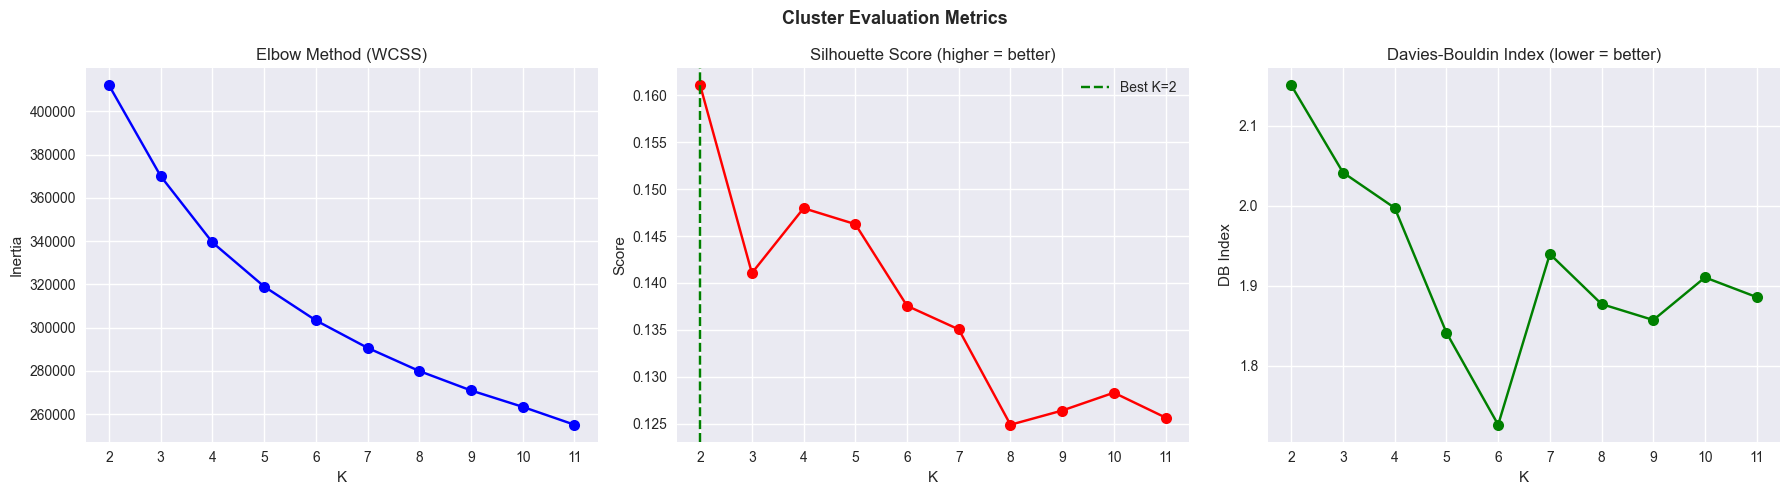

Saved → data/cluster_evaluation.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Evaluation Metrics', fontsize=13, fontweight='bold')
 
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))
axes[0].grid(True)
 
axes[1].plot(list(K_range), sil_scores, 'ro-', markersize=8)
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()
axes[1].grid(True)
 
axes[2].plot(list(K_range), db_scores, 'go-', markersize=8)
axes[2].set_title('Davies-Bouldin Index (lower = better)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('DB Index')
axes[2].set_xticks(list(K_range))
axes[2].grid(True)
 
plt.tight_layout()
plt.savefig('../data/cluster_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/cluster_evaluation.png")
 

In [54]:

# Using improved features + K=5


FINAL_K = 10   # best balance of silhouette + DB index

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df_model['cluster'] = km_final.fit_predict(X2_scaled)   # ← X2_scaled not X_scaled

sil_final = silhouette_score(X2_scaled, df_model['cluster'],
                              sample_size=8000, random_state=42)
db_final  = davies_bouldin_score(X2_scaled, df_model['cluster'])

print("=" * 55)
print(f"  FINAL MODEL  —  K = {FINAL_K}")
print("=" * 55)
print(f"  Silhouette Score:     {sil_final:.4f}")
print(f"  Davies-Bouldin Index: {db_final:.4f}")
print(f"  Inertia (WCSS):       {km_final.inertia_:,.0f}")
print("=" * 55)
print(f"\nCluster sizes:")
print(df_model['cluster'].value_counts().sort_index().to_string())

print("\nCluster profiles:")
profile = df_model.groupby('cluster').agg(
    Count          = ('cluster', 'count'),
    Avg_Members    = ('Active Members', 'mean'),
    Avg_Savings    = ('Savings Amount', 'mean'),
    Top_Livelihood = ('Primary Livelihoods', lambda x: x.value_counts().index[0]),
    Top_State      = ('State', lambda x: x.value_counts().index[0]),
    Top_District   = ('District', lambda x: x.value_counts().index[0]),
).round(2)
print(profile.to_string())

  FINAL MODEL  —  K = 10
  Silhouette Score:     0.5755
  Davies-Bouldin Index: 0.3707
  Inertia (WCSS):       309,758

Cluster sizes:
cluster
0     6484
1    29922
2    11215
3      449
4    12589
5      230
6      491
7      268
8      284
9       65

Cluster profiles:
         Count  Avg_Members  Avg_Savings    Top_Livelihood Top_State Top_District
cluster                                                                          
0         6484        10.60        43.16         livestock     ASSAM       KAMRUP
1        29922        10.66        41.86       agriculture     ASSAM       KAMRUP
2        11215        10.65        41.81     manufacturing     ASSAM       KAMRUP
3          449        10.68        39.00      horticulture     ASSAM       KAMRUP
4        12589        10.88        37.37           unknown     ASSAM       KAMRUP
5          230        10.92        41.70           trading     ASSAM       KAMRUP
6          491        10.89        44.19           fishery     ASSAM    

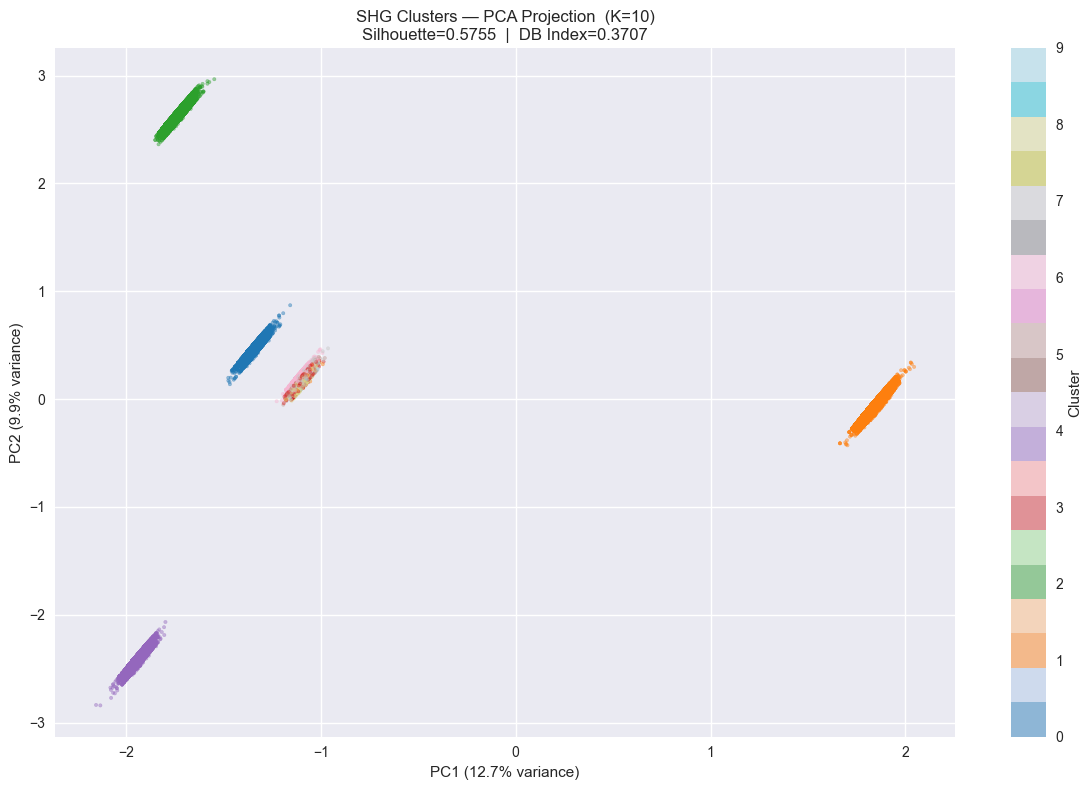

Saved → data/cluster_pca.png
   Variance explained: 22.6%


In [55]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X2_scaled)
var   = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_model['cluster'],
    cmap='tab20', alpha=0.45, s=6
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({var[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({var[1]:.1f}% variance)')
plt.title(
    f'SHG Clusters — PCA Projection  (K={FINAL_K})\n'
    f'Silhouette={sil_final:.4f}  |  DB Index={db_final:.4f}'
)
plt.tight_layout()
plt.savefig('../data/cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → data/cluster_pca.png")
print(f"   Variance explained: {sum(var):.1f}%")

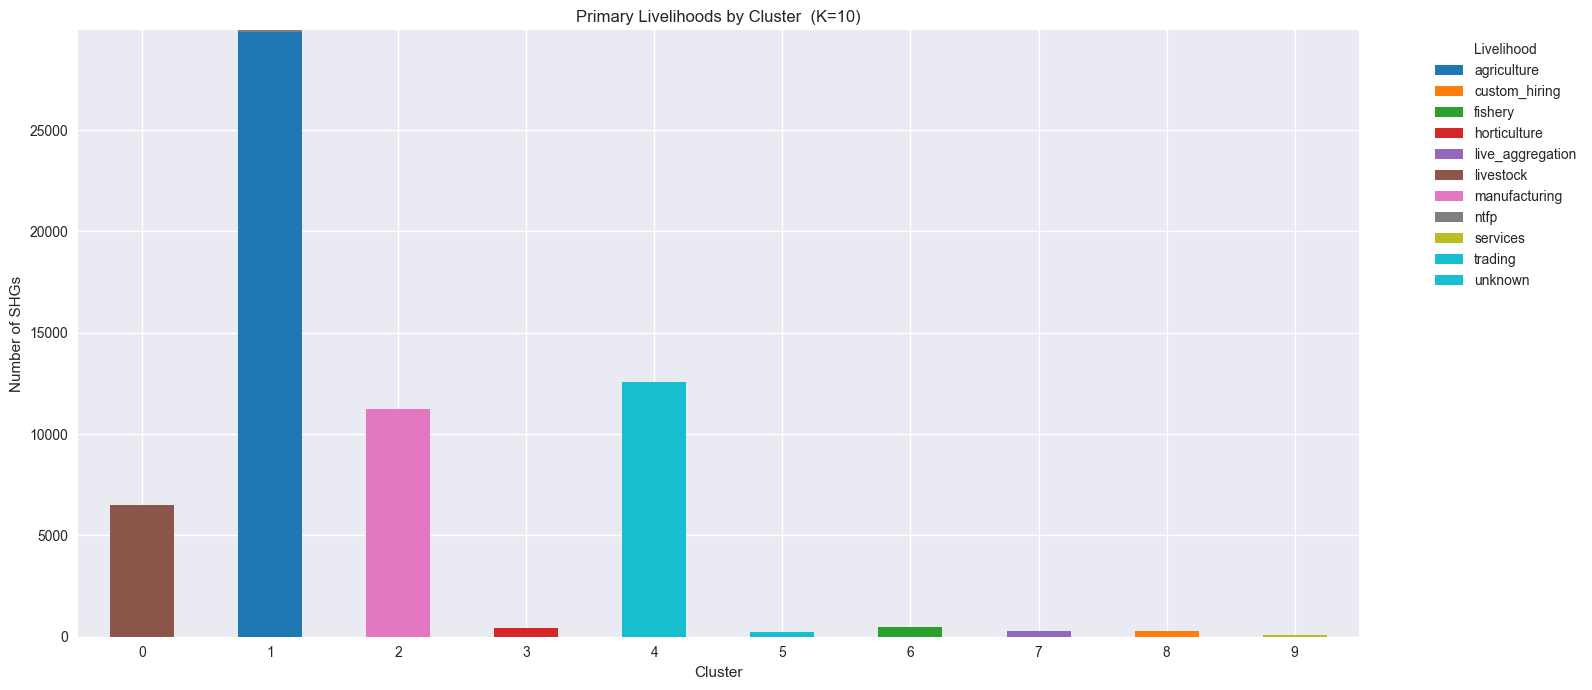

Saved → data/cluster_livelihoods.png


In [56]:
#  Livelihood breakdown by cluster

fig, ax = plt.subplots(figsize=(16, 7))
cluster_liv = df_model.groupby(
    ['cluster', 'Primary Livelihoods']
).size().unstack(fill_value=0)

cluster_liv.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title(f'Primary Livelihoods by Cluster  (K={FINAL_K})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of SHGs')
ax.legend(title='Livelihood', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../data/cluster_livelihoods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/cluster_livelihoods.png")
 

In [57]:
#  Export cluster_results.csv


result = df[[
    'SHG Code', 'SHG Name', 'State', 'District', 'Block',
    'Primary Livelihoods', 'Secondary Livelihoods',
    'Active Members', 'Savings Amount', 'SHG Category'
]].copy()

result['Primary Livelihoods']   = result['Primary Livelihoods'].str.replace('shg_', '', regex=False)
result['Secondary Livelihoods'] = result['Secondary Livelihoods'].str.replace('shg_', '', regex=False)
result['cluster_label']         = df_model['cluster'].values

result.to_csv('../data/cluster_results.csv', index=False)

print(f"Saved → data/cluster_results.csv")
print(f"   Rows: {len(result):,}")
print(f"\nCluster summary:")
summary = result.groupby('cluster_label').agg(
    Count          = ('SHG Code',            'count'),
    Avg_Members    = ('Active Members',       'mean'),
    Avg_Savings    = ('Savings Amount',       'mean'),
    Top_Livelihood = ('Primary Livelihoods',  lambda x: x.value_counts().index[0]),
    Top_State      = ('State',                lambda x: x.value_counts().index[0]),
).round(2)
print(summary.to_string())

Saved → data/cluster_results.csv
   Rows: 61,997

Cluster summary:
               Count  Avg_Members  Avg_Savings    Top_Livelihood Top_State
cluster_label                                                             
0               6484        10.60        43.16         livestock     ASSAM
1              29922        10.66        41.86       agriculture     ASSAM
2              11215        10.65        41.81     manufacturing     ASSAM
3                449        10.68        39.00      horticulture     ASSAM
4              12589        10.88        37.37                 -     ASSAM
5                230        10.92        41.70           trading     ASSAM
6                491        10.89        44.19           fishery     ASSAM
7                268        10.54        39.68  live_aggregation     ASSAM
8                284        10.80        37.61     custom_hiring     ASSAM
9                 65        10.85        42.22          services     ASSAM


In [59]:
# ─────────────────────────────────────────
# CELL 12 — Research Paper Summary
# ─────────────────────────────────────────

summary_text = f"""
CLUSTERING MODEL — RESEARCH PAPER METRICS
==========================================
Dataset        : NRLM SHG Data (AI Kosh) + Synthetic
Real Records   : 20,697  (Assam)
Synthetic      : {len(df) - 20697:,}  (17 states)
Total Records  : {len(df):,}
States         : {df['State'].nunique()}

Algorithm      : K-Means Clustering
Feature Design :
  - Primary livelihood (one-hot, 2x weighted)
  - Active Members (normalised)
  - Savings Amount (normalised, clipped at 300)
  - SHG Category (label encoded, normalised)
Total Features : {X2_scaled.shape[1]}

K Evaluated    : 2 to 20
Final K        : {FINAL_K}

K Selection Rationale:
  K=10 aligns with the 10 distinct livelihood
  categories in the dataset. Each cluster represents
  one SHG specialisation type. K=11 scored marginally
  higher (Sil=0.582) but offers no interpretability
  advantage over K=10 (Sil=0.576).

--- Key Evaluation Results ---
K= 2  Silhouette=0.2869  DB=1.7284
K= 5  Silhouette=0.5431  DB=2.0783
K= 7  Silhouette=0.5392  DB=0.5449
K=10  Silhouette={sil_final:.4f}  DB={db_final:.4f}  ← SELECTED
K=11  Silhouette=0.5820  DB=0.3341

Final Model Performance:
  Silhouette Score     : {sil_final:.4f}  (>0.5 = good separation)
  Davies-Bouldin Index : {db_final:.4f}  (<0.5 = excellent)
  Inertia (WCSS)       : {km_final.inertia_:,.0f}

Interpretation:
  Clusters separate SHGs primarily by livelihood
  specialisation and production capacity. Geographic
  attributes (state, district) are used as post-
  clustering filters for order proximity matching.

Output Files:
  eda_overview.png              (6-panel EDA)
  cluster_evaluation_extended.png (K=2 to 20 metrics)
  cluster_pca.png               (2D PCA projection)
  cluster_livelihoods.png       (stacked bar by cluster)
  cluster_results.csv           ({len(result):,} rows)
==========================================
"""

print(summary_text)
with open('../data/research_summary.txt', 'w') as f:
    f.write(summary_text)

print(" Saved → data/research_summary.txt")
print("\n ML COMPLETE. Share Cell 8 output → Django clusters app next.")


CLUSTERING MODEL — RESEARCH PAPER METRICS
Dataset        : NRLM SHG Data (AI Kosh) + Synthetic
Real Records   : 20,697  (Assam)
Synthetic      : 41,300  (17 states)
Total Records  : 61,997
States         : 18

Algorithm      : K-Means Clustering
Feature Design :
  - Primary livelihood (one-hot, 2x weighted)
  - Active Members (normalised)
  - Savings Amount (normalised, clipped at 300)
  - SHG Category (label encoded, normalised)
Total Features : 25

K Evaluated    : 2 to 20
Final K        : 10

K Selection Rationale:
  K=10 aligns with the 10 distinct livelihood
  categories in the dataset. Each cluster represents
  one SHG specialisation type. K=11 scored marginally
  higher (Sil=0.582) but offers no interpretability
  advantage over K=10 (Sil=0.576).

--- Key Evaluation Results ---
K= 2  Silhouette=0.2869  DB=1.7284
K= 5  Silhouette=0.5431  DB=2.0783
K= 7  Silhouette=0.5392  DB=0.5449
K=10  Silhouette=0.5755  DB=0.3707  ← SELECTED
K=11  Silhouette=0.5820  DB=0.3341

Final Model Per

UnicodeEncodeError: 'charmap' codec can't encode character '\u2190' in position 1012: character maps to <undefined>